Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


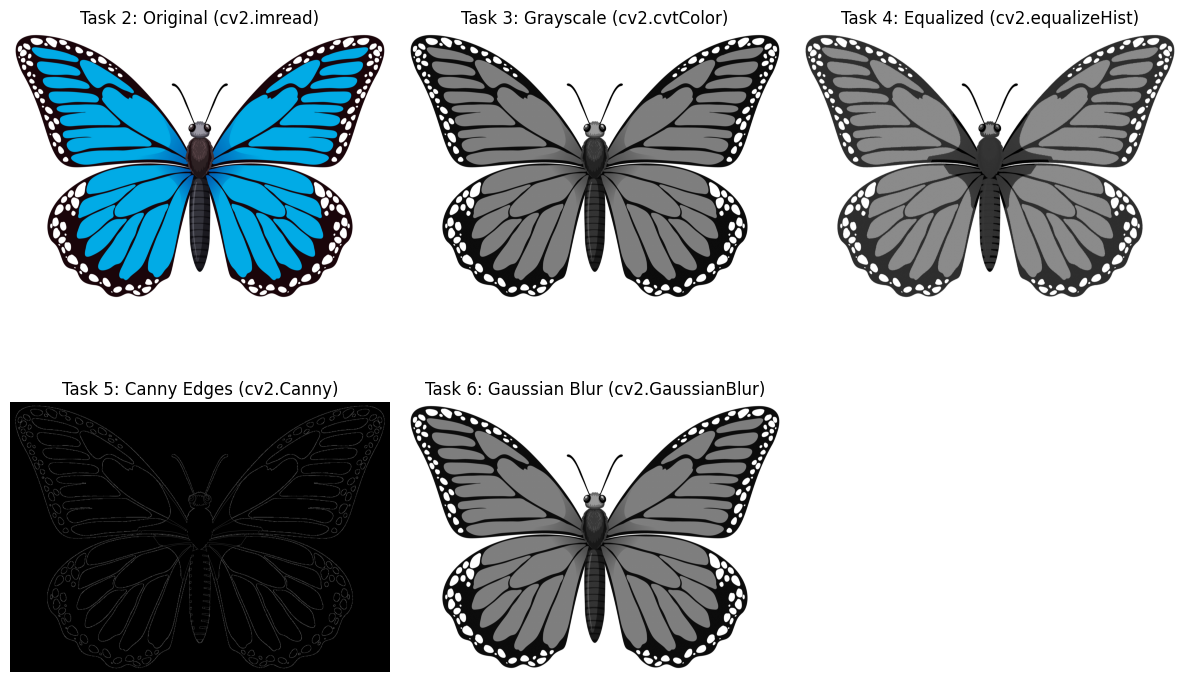

In [14]:
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

image_path = '/content/drive/MyDrive/ColabNotebooks/image.jpg'

bgr = cv2.imread(image_path)
if bgr is None:
    raise ValueError(f"Failed to read image: {image_path}")

gray  = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)   # Task 3
eq    = cv2.equalizeHist(gray)                  # Task 4
edges = cv2.Canny(eq, 100, 200)               # Task 5
blur  = cv2.GaussianBlur(gray, (5, 5), 0)       # Task 6

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)      # For matplotlib (Task 2)

images = [
    (rgb,  "Task 2: Original (cv2.imread)"),
    (gray, "Task 3: Grayscale (cv2.cvtColor)"),
    (eq,   "Task 4: Equalized (cv2.equalizeHist)"),
    (edges,"Task 5: Canny Edges (cv2.Canny)"),
    (blur, "Task 6: Gaussian Blur (cv2.GaussianBlur)")
]

plt.figure(figsize=(12, 8))
for i, (img, title) in enumerate(images, 1):
    plt.subplot(2, 3, i)

    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()